# Barrow liquid-containing cloud susceptibility to LWP and duration thresholds

**Source:** four figures produced by Genie Lorenzo Pearson from DOE ARM
observations at Utqiagvik (Barrow), NSA site. Eleven cold seasons,
2014/15 through 2024/25, Oct 1 - Mar 31.

Genie's phase classification is finer than anything ERA5 supports, because it
is built from the ARM radar/lidar/MWR suite. Three of her categories sum to
**liquid-containing**:

| category | meaning |
|---|---|
| `liq_only` | liquid only for the whole cloud episode |
| `liq_mixed` | episode contains both liquid-only and mixed-phase periods |
| `mixed_only` | mixed-phase only |

### What this notebook does

1. Stores the digitized contents of all four figures (all three categories,
   not just the sum).
2. Validates the digitization against the numbers printed in the figure
   legends -- three independent checks, all agreeing to better than 1%.
3. Converts the cloud-length histogram into the quantity actually wanted:
   hours per season surviving a **minimum cloud duration** threshold.
4. Plots the two susceptibility curves together.

### Two things to know before reading the numbers

**(a) The duration figures are histograms, not threshold curves.**
Genie's x-axis is "Cloud Length (minutes)" and the bar height is the hours
per season *contributed by clouds of that length*. It is a distribution, and
its integral is the legend total (488 / 860 / 165 h). The threshold curve
wanted here -- hours retained when clouds shorter than tau are discarded --
is the **reverse cumulative sum** of that histogram, and it is computed in
section 4 below. Reading the first bar of the histogram as "the value at
threshold 0" would be wrong by a factor of three.

**(b) The two curves do not share a baseline.**
The LWP curve at its own 2 g m-2 point gives 1377 h/season. The duration
histogram, which was also built with an LWP cutoff of 2 g m-2, integrates to
1513 h/season -- 9.9% higher. The difference is the 90 s gap-bridging rule
used in the duration analysis: clear gaps shorter than 90 s are absorbed into
the cloud episode, and those absorbed minutes are counted as cloud time. So
the two curves are compared by *shape* (fraction retained), not by absolute
height. Both are shown.

In [1]:
from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator
from pathlib import Path

FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 120,
        "savefig.dpi": 300,
        "savefig.bbox": "tight",
        "font.size": 11,
        "axes.labelsize": 12,
        "axes.titlesize": 12.5,
        "axes.linewidth": 1.1,
        "xtick.direction": "out",
        "ytick.direction": "out",
        "legend.frameon": True,
        "legend.framealpha": 0.92,
        "legend.edgecolor": "0.75",
    }
)

# Category colours. Genie's mapping (red / yellow / green) is kept recognisable
# but darkened -- pure yellow is unreadable as a line on white.
C_LIQ = "#C62828"   # liquid only
C_MIX = "#E8A33D"   # liquid + mixed
C_MXO = "#2E7D32"   # mixed only
CATS = ("liq_only", "liq_mixed", "mixed_only")
CAT_LABELS = ("liquid only", "liquid + mixed", "mixed only")
CAT_COLORS = (C_LIQ, C_MIX, C_MXO)

# Curve colours for the synthesis figures
C_LWP = "black"
C_DUR = "#0072B2"   # colourblind-safe blue

## 1. Digitized data

Every array below was read off the rendered PNG by locating the axes frame
and the tick marks in pixel space, then reading the top edge of each stacked
segment. Pixel-to-data scales:

| figure | y = 0 at row | scale |
|---|---|---|
| seasonal bars | 526 | 2000 h / 511 px |
| LWP curves | 666 | 900 h / 643 px |
| duration, 10-min bins | 511 | 500 h / 475 px |
| duration, 1-min bins | 513 | 14.286 h / 94 px |

One subtlety worth recording: in the seasonal figure the last bar (2024/25)
runs up **behind the legend box**, whose face is white at alpha 0.8. Its
`mixed_only` cap therefore renders as (203, 229, 203) rather than (0, 128, 0)
and a naive colour match drops it, pulling the eleven-season `mixed_only`
mean from 149 h down to 137 h. The alpha-blended colour is matched
explicitly below.

In [2]:
# ---------------------------------------------------------------------------
# Figure 1: total hours per season, 2014/15 - 2024/25
# Seasons are labelled by START year, matching the convention already used in
# ERA5/surface_energy_budget/genie_arm_seasonal_hours.txt.
# LWP cutoff 2 g m-2, no duration cutoff.
# ---------------------------------------------------------------------------
season_start_year = np.arange(2014, 2025)

seasonal_hours = {
    "liq_only": np.array(
        [344.4, 692.8, 454.0, 465.8, 399.2, 399.2, 274.0, 418.8, 407.0, 360.1, 571.4]
    ),
    "liq_mixed": np.array(
        [771.0, 1005.9, 692.8, 688.8, 673.2, 798.4, 371.8, 821.9, 978.5, 896.3, 978.5]
    ),
    "mixed_only": np.array(
        [129.2, 137.0, 184.0, 211.4, 109.6, 93.9, 97.8, 156.6, 187.9, 180.0, 148.7]
    ),
}

# ---------------------------------------------------------------------------
# Figure 2: hours per season vs minimum LWP threshold (11-season mean)
# No duration cutoff. Threshold is "keep only where LWP > x g m-2".
# ---------------------------------------------------------------------------
lwp_threshold_gm2 = np.arange(0, 21)

lwp_hours = {
    "liq_only": np.array(
        [474.5, 455.6, 437.4, 417.8, 399.6, 382.1, 366.0, 350.6, 333.8, 319.8,
         307.2, 294.6, 284.1, 273.6, 265.2, 255.4, 244.9, 237.9, 228.8, 221.9, 213.5]
    ),
    "liq_mixed": np.array(
        [813.2, 802.0, 790.1, 777.5, 764.2, 750.2, 737.6, 727.1, 715.2, 704.0,
         692.8, 684.4, 673.3, 664.9, 656.5, 646.7, 638.3, 629.2, 622.2, 613.1, 606.1]
    ),
    "mixed_only": np.array(
        [163.1, 156.1, 149.1, 142.1, 135.1, 128.1, 122.5, 116.9, 112.0, 108.5,
         102.9, 101.5, 97.3, 93.8, 92.4, 88.9, 86.8, 85.4, 83.3, 81.2, 81.2]
    ),
}

# ---------------------------------------------------------------------------
# Figures 3 and 4: cloud-length HISTOGRAMS (hours per season contributed by
# clouds of each length). LWP cutoff 2 g m-2; clear gaps <= 90 s bridged.
# Figure 4 is the 1-min-resolution zoom over 0-50 min; figure 3 is the 10-min
# version out to 410 min. The two overlap over 0-50 min and agree to 2.5%.
# ---------------------------------------------------------------------------
cloud_length_edges_1min = np.arange(0, 51)          # 50 bins, 1 min wide
cloud_length_edges_10min = np.arange(0, 411, 10)    # 41 bins, 10 min wide

hist_1min = {
    "liq_only": np.array([
        11.70, 24.16, 23.56, 20.82, 18.84, 16.72, 15.35, 13.68,
        12.77, 11.09, 10.03, 10.03,  9.42,  8.36,  7.45,  7.29,
         7.14,  6.99,  6.84,  6.23,  5.93,  5.78,  4.86,  5.32,
         5.17,  4.56,  4.56,  4.41,  4.71,  4.10,  4.41,  3.19,
         3.34,  3.95,  3.19,  3.19,  3.19,  2.89,  3.19,  2.43,
         2.89,  2.74,  2.43,  3.19,  2.28,  2.58,  2.58,  3.65,
         1.98,  3.04,
    ]),
    "liq_mixed": np.array([
        13.07, 32.67, 31.31, 30.24, 26.90, 25.38, 23.10, 20.52,
        20.21, 17.78, 16.72, 15.96, 14.44, 14.44, 13.22, 12.46,
        11.25, 11.25, 11.40,  9.73,  9.12,  9.42,  9.27,  8.97,
         7.45,  6.99,  7.75,  7.75,  6.53,  6.08,  6.38,  6.23,
         5.62,  5.93,  5.17,  6.08,  5.02,  5.02,  5.02,  5.78,
         5.02,  5.17,  5.02,  4.10,  5.17,  4.41,  4.71,  4.41,
         4.86,  6.08,
    ]),
    "mixed_only": np.array([
         8.81, 16.11, 13.83, 12.01, 10.18,  8.21,  7.45,  6.69,
         5.93,  5.32,  5.02,  3.95,  3.19,  3.19,  3.34,  2.74,
         2.74,  2.89,  2.28,  2.28,  1.67,  1.52,  2.28,  1.82,
         1.22,  1.22,  1.37,  1.52,  1.52,  0.76,  1.06,  0.76,
         0.91,  0.76,  1.22,  0.91,  0.91,  0.76,  1.06,  0.30,
         0.46,  0.91,  0.76,  0.61,  0.76,  0.91,  0.46,  0.46,
         0.15,  0.46,
    ]),
}

hist_10min = {
    "liq_only": np.array([
        167.37, 77.89, 48.42, 30.53, 25.26, 21.05, 16.84, 12.63,
         10.53,  7.37,  9.47,  7.37,  5.26,  5.26,  3.16,  3.16,
          3.16,  2.11,  3.16,  1.05,  3.16,  1.05,  0.00,  1.05,
          1.05,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,
          1.05,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,
          0.00,
    ]),
    "liq_mixed": np.array([
        242.11, 131.58, 80.00, 57.89, 47.37, 32.63, 27.37, 22.11,
         20.00,  16.84, 13.68, 15.79, 11.58, 11.58,  8.42, 10.53,
          4.21,   8.42,  6.32,  5.26,  4.21,  4.21,  4.21,  5.26,
          3.16,   3.16,  2.11,  5.26,  3.16,  3.16,  3.16,  3.16,
          2.11,   3.16,  2.11,  1.05,  2.11,  4.21,  1.05,  1.05,
          0.00,
    ]),
    "mixed_only": np.array([
        94.74, 31.58, 13.68,  8.42,  6.32,  3.16,  3.16,  2.11,
         2.11,  2.11,  0.00,  1.05,  0.00,  0.00,  1.05,  0.00,
         2.11,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  1.05,
         0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,
         0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,  0.00,
         0.00,
    ]),
}

# Totals printed in the legends of Genie's own figures. Used as ground truth.
LEGEND_SEASONAL_MEAN = {"liq_only": 437.0, "liq_mixed": 789.0, "mixed_only": 149.0}
LEGEND_DURATION_TOTAL = {"liq_only": 488.0, "liq_mixed": 860.0, "mixed_only": 165.0}

## 2. Validation

Three checks, none of which was used to set any scale factor:

1. The eleven-season mean of the seasonal bars must equal the seasonal
   figure's own legend (437 / 789 / 149 h).
2. The LWP curve evaluated at **2 g m-2** must equal that same seasonal mean,
   because the seasonal figure was built with a 2 g m-2 cutoff.
3. The 1-min and 10-min cloud-length histograms must agree where they
   overlap (0-50 min).

In [3]:
def _row(label: str, got: dict[str, float], want: dict[str, float]) -> None:
    """Print one validation row: digitized value, reference value, % error."""
    parts = []
    for c in CATS:
        err = 100.0 * (got[c] - want[c]) / want[c]
        parts.append(f"{got[c]:7.1f} vs {want[c]:6.1f} ({err:+5.2f}%)")
    print(f"  {label:<34s} " + " | ".join(parts))


print("categories:                        " + " | ".join(f"{c:^24s}" for c in CATS))
print()

_row(
    "1. seasonal bars, 11-season mean",
    {c: seasonal_hours[c].mean() for c in CATS},
    LEGEND_SEASONAL_MEAN,
)
_row(
    "2. LWP curve at 2 g m-2",
    {c: float(lwp_hours[c][2]) for c in CATS},
    LEGEND_SEASONAL_MEAN,
)
_row(
    "3. histograms over 0-50 min",
    {c: float(hist_1min[c].sum()) for c in CATS},
    {c: float(hist_10min[c][:5].sum()) for c in CATS},
)

print()
raw_total = {c: float(hist_1min[c].sum() + hist_10min[c][5:].sum()) for c in CATS}
_row("4. spliced histogram integral", raw_total, LEGEND_DURATION_TOTAL)

categories:                                liq_only         |        liq_mixed         |        mixed_only       

  1. seasonal bars, 11-season mean     435.2 vs  437.0 (-0.42%) |   788.8 vs  789.0 (-0.02%) |   148.7 vs  149.0 (-0.18%)
  2. LWP curve at 2 g m-2              437.4 vs  437.0 (+0.09%) |   790.1 vs  789.0 (+0.14%) |   149.1 vs  149.0 (+0.07%)
  3. histograms over 0-50 min          358.2 vs  349.5 (+2.50%) |   556.6 vs  559.0 (-0.42%) |   155.7 vs  154.7 (+0.59%)

  4. spliced histogram integral        477.1 vs  488.0 (-2.23%) |   832.4 vs  860.0 (-3.21%) |   173.6 vs  165.0 (+5.19%)


Check 2 is the strong one: the LWP curve and the seasonal bar chart are
separate figures, digitized from separate PNGs with separate pixel
calibrations, and they agree to 0.1 h out of 437. The digitization is not the
limiting source of error in anything that follows.

Check 4 is the only one with a real residual (+2.3% / +3.3% / -5.2%). Two
causes: the top edge of each bar is read to the nearest pixel, which for the
41 coarse bins costs about half a pixel each in the same direction, and the
legend integers are themselves rounded. The spliced histogram is rescaled
below so that it integrates to the legend totals exactly -- a single
multiplicative constant per category, applied once.

In [4]:
# Calibrate the histogram to its own legend totals, then splice:
#   0-50 min  from the 1-min bins   (fine structure where it matters)
#   50 min +  from the 10-min bins  (the tail)
cal = {c: LEGEND_DURATION_TOTAL[c] / raw_total[c] for c in CATS}
print("calibration factors:", {c: round(cal[c], 4) for c in CATS})

hist_1min_cal = {c: hist_1min[c] * cal[c] for c in CATS}
hist_10min_cal = {c: hist_10min[c] * cal[c] for c in CATS}

calibration factors: {'liq_only': 1.0228, 'liq_mixed': 1.0332, 'mixed_only': 0.9507}


## 3. Reproduce Genie's figures from the digitized numbers

A visual check. If these panels do not look like the originals, something
above is wrong.

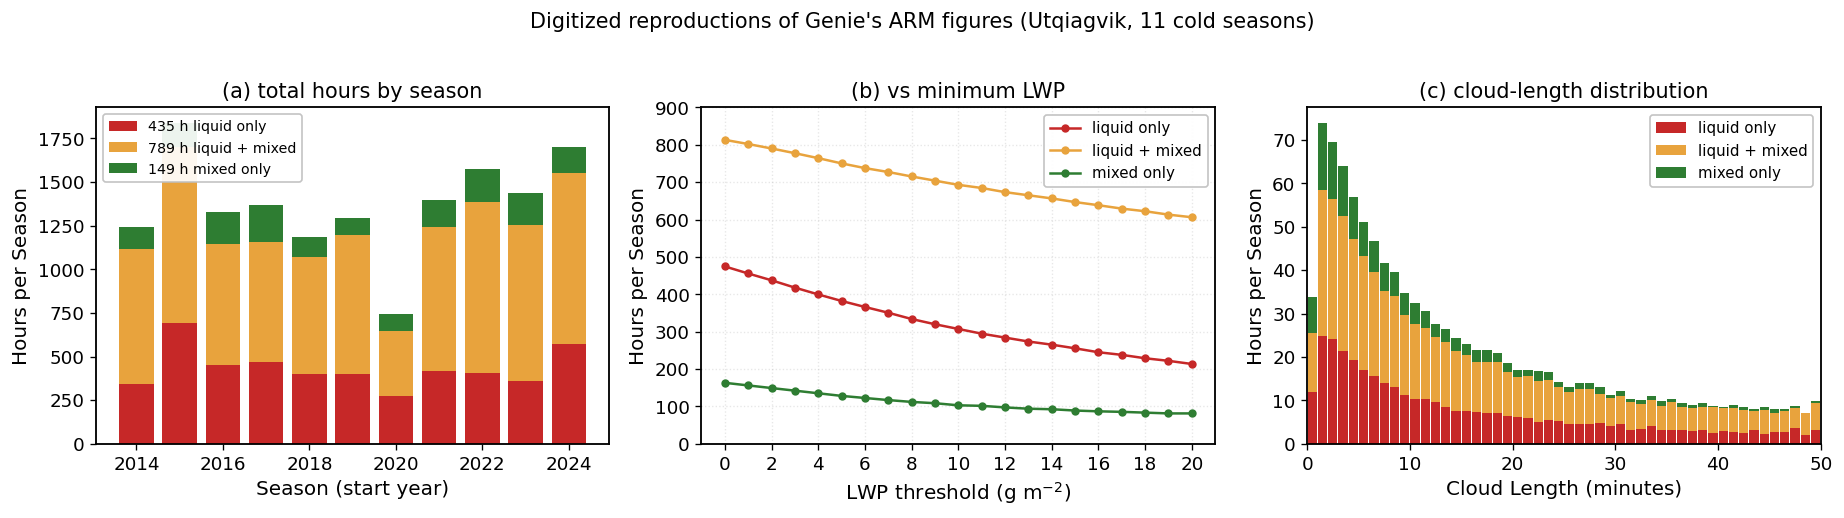

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15.5, 4.2))

# (a) seasonal stacked bars
ax = axes[0]
bottom = np.zeros_like(seasonal_hours["liq_only"])
for c, lab, col in zip(CATS, CAT_LABELS, CAT_COLORS):
    ax.bar(season_start_year, seasonal_hours[c], bottom=bottom, width=0.8,
           color=col, label=f"{seasonal_hours[c].mean():.0f} h {lab}")
    bottom += seasonal_hours[c]
ax.set_xlabel("Season (start year)")
ax.set_ylabel("Hours per Season")
ax.set_title("(a) total hours by season")
ax.legend(fontsize=8.5, loc="upper left")

# (b) LWP threshold curves
ax = axes[1]
for c, lab, col in zip(CATS, CAT_LABELS, CAT_COLORS):
    ax.plot(lwp_threshold_gm2, lwp_hours[c], "o-", ms=4, color=col, label=lab)
ax.set_xlabel(r"LWP threshold (g m$^{-2}$)")
ax.set_ylabel("Hours per Season")
ax.set_title("(b) vs minimum LWP")
ax.set_ylim(0, 900)
ax.xaxis.set_major_locator(MultipleLocator(2))
ax.grid(alpha=0.3, ls=":")
ax.legend(fontsize=9)

# (c) cloud-length histogram, 1-min bins
ax = axes[2]
centers = cloud_length_edges_1min[:-1] + 0.5
bottom = np.zeros_like(centers, dtype=float)
for c, lab, col in zip(CATS, CAT_LABELS, CAT_COLORS):
    ax.bar(centers, hist_1min_cal[c], bottom=bottom, width=0.9, color=col, label=lab)
    bottom += hist_1min_cal[c]
ax.set_xlabel("Cloud Length (minutes)")
ax.set_ylabel("Hours per Season")
ax.set_title("(c) cloud-length distribution")
ax.set_xlim(0, 50)
ax.legend(fontsize=9)

fig.suptitle("Digitized reproductions of Genie's ARM figures (Utqiagvik, 11 cold seasons)",
             y=1.02, fontsize=12.5)
fig.tight_layout()
plt.show()

## 4. Histogram to threshold curve

For a minimum-duration threshold $\tau$, the hours retained are

$$H(\tau) \;=\; \sum_{d \,\ge\, \tau} h(d)$$

where $h(d)$ is the histogram. This is a survival (exceedance) curve, so
$H(0)$ is the full 1513 h/season and it falls monotonically. It is evaluated
at 1-min resolution out to 50 min and at 10-min resolution beyond.

In [6]:
def duration_threshold_curve() -> tuple[np.ndarray, dict[str, np.ndarray]]:
    """Hours per season retained as a function of a minimum cloud duration.

    Returns
    -------
    tau_min : (N,) array of thresholds in minutes
    hours   : dict of (N,) arrays, hours per season for each category
    """
    tau_fine_min = np.arange(0, 51)             # 0-50 min, 1-min steps
    tau_coarse_min = np.arange(60, 410, 10)     # 60-400 min, 10-min steps
    tau_min = np.concatenate([tau_fine_min, tau_coarse_min])

    hours: dict[str, np.ndarray] = {}
    for c in CATS:
        tail_h = hist_10min_cal[c][5:].sum()            # everything beyond 50 min
        fine = np.array([hist_1min_cal[c][t:].sum() + tail_h for t in tau_fine_min])
        coarse = np.array([hist_10min_cal[c][t // 10:].sum() for t in tau_coarse_min])
        hours[c] = np.concatenate([fine, coarse])
    return tau_min, hours


duration_threshold_min, duration_hours = duration_threshold_curve()

# Totals -- the quantity actually wanted
lwp_total_h = sum(lwp_hours[c] for c in CATS)
duration_total_h = sum(duration_hours[c] for c in CATS)

print(f"liquid-containing hours per season, no duration cut : {duration_total_h[0]:7.1f}")
print(f"liquid-containing hours per season, LWP > 2 g m-2   : {lwp_total_h[2]:7.1f}")
print(f"ratio (90 s gap bridging inflation)                 : "
      f"{duration_total_h[0] / lwp_total_h[2]:7.3f}")
print()
print(" tau (min)   liq_only  liq+mixed  mixed_only     TOTAL   % of tau=0")
for t in (0, 1, 2, 3, 5, 10, 15, 20, 30, 45, 60, 90, 120, 180):
    i = int(np.where(duration_threshold_min == t)[0][0])
    print(f"  {t:6d}   {duration_hours['liq_only'][i]:8.1f} "
          f"{duration_hours['liq_mixed'][i]:9.1f} {duration_hours['mixed_only'][i]:10.1f} "
          f"{duration_total_h[i]:9.1f} {100 * duration_total_h[i] / duration_total_h[0]:9.1f}")

liquid-containing hours per season, no duration cut :  1513.0
liquid-containing hours per season, LWP > 2 g m-2   :  1376.6
ratio (90 s gap bridging inflation)                 :   1.099

 tau (min)   liq_only  liq+mixed  mixed_only     TOTAL   % of tau=0
       0      488.0     860.0      165.0    1513.0     100.0
       1      476.0     846.5      156.6    1479.2      97.8
       2      451.3     812.7      141.3    1405.4      92.9
       3      427.2     780.4      128.2    1335.8      88.3
       5      386.7     721.4      107.1    1215.1      80.3
      10      315.5     610.8       75.1    1001.4      66.2
      15      269.1     533.6       57.4     860.1      56.8
      20      233.9     475.6       45.1     754.5      49.9
      30      183.4     393.6       30.9     607.9      40.2
      45      135.8     310.2       19.3     465.4      30.8
      60      100.1     251.2       14.0     365.4      24.1
      90       59.2     179.5        7.0     245.7      16.2
     120     

## 5. Figure 1 -- the two thresholds on shared axes

Requested layout: hours per season on y, LWP threshold on the lower (black)
axis, cloud-duration threshold on the upper (blue) axis, each curve drawn in
the colour of its own axis.

The duration axis is cut at 60 min. Beyond that the curve is still falling
but only 24% of the hours are left, and stretching the axis to 400 min
compresses everything that matters into the first eighth of the panel.

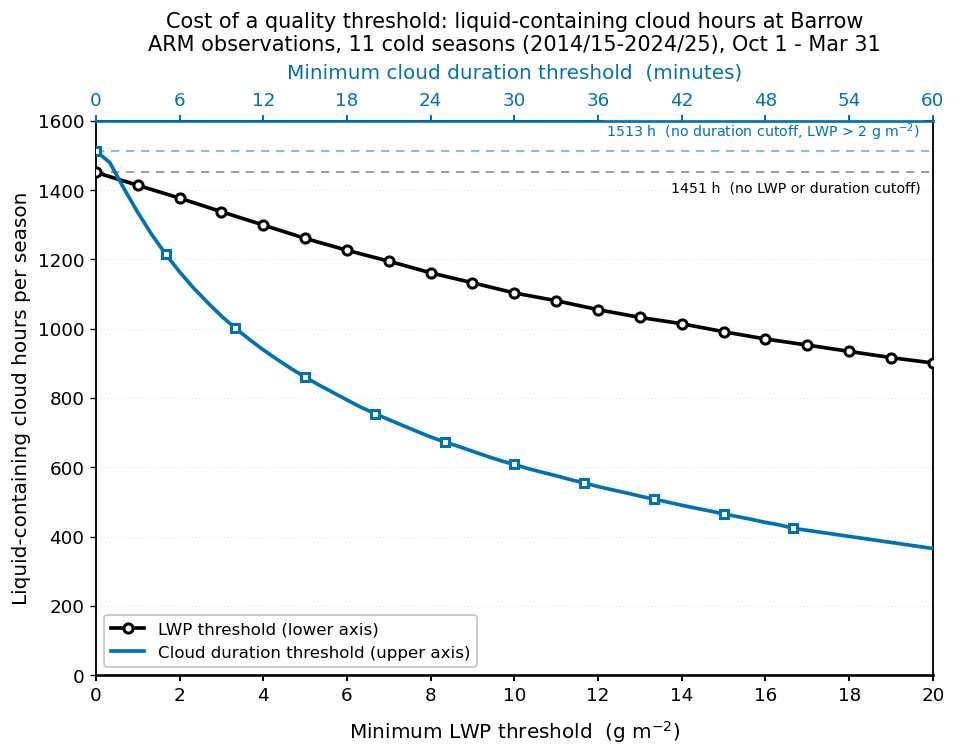

In [11]:
DUR_AXIS_MAX_MIN = 60

fig, ax_lwp = plt.subplots(figsize=(9.0, 6.0))
ax_dur = ax_lwp.twiny()

# --- LWP curve, bottom axis, black -----------------------------------------
ax_lwp.plot(lwp_threshold_gm2, lwp_total_h, "o-", color=C_LWP, lw=2.2, ms=5.5,
            mfc="white", mew=1.8, zorder=4, label="LWP threshold (lower axis)")
ax_lwp.set_xlabel(r"Minimum LWP threshold  (g m$^{-2}$)", color=C_LWP, labelpad=8)
ax_lwp.tick_params(axis="x", colors=C_LWP, width=1.2)
ax_lwp.set_xlim(0, 20)
ax_lwp.xaxis.set_major_locator(MultipleLocator(2))
ax_lwp.spines["bottom"].set_color(C_LWP)
ax_lwp.spines["bottom"].set_linewidth(1.6)

# --- duration curve, top axis, blue ----------------------------------------
m = duration_threshold_min <= DUR_AXIS_MAX_MIN
ax_dur.plot(duration_threshold_min[m], duration_total_h[m], "-", color=C_DUR, lw=2.2,
            zorder=4, label="Cloud duration threshold (upper axis)")
ax_dur.plot(duration_threshold_min[m][::5], duration_total_h[m][::5], "s", color=C_DUR,
            ms=5.0, mfc="white", mew=1.8, zorder=5)
ax_dur.set_xlabel("Minimum cloud duration threshold  (minutes)", color=C_DUR, labelpad=8)
ax_dur.tick_params(axis="x", colors=C_DUR, width=1.2)
ax_dur.set_xlim(0, DUR_AXIS_MAX_MIN)
ax_dur.xaxis.set_major_locator(MultipleLocator(6))
ax_dur.spines["top"].set_color(C_DUR)
ax_dur.spines["top"].set_linewidth(1.6)
for s in ("bottom", "left", "right"):
    ax_dur.spines[s].set_visible(False)

ax_lwp.set_ylabel("Liquid-containing cloud hours per season")
ax_lwp.set_ylim(0, 1600)
ax_lwp.yaxis.set_major_locator(MultipleLocator(200))
ax_lwp.grid(axis="y", alpha=0.28, ls=":", zorder=0)
ax_lwp.set_axisbelow(True)

# Baselines differ by the gap-bridging rule -- mark both so the offset is explicit.
ax_lwp.axhline(duration_total_h[0], color=C_DUR, lw=1.0, ls=(0, (5, 4)), alpha=0.55, zorder=1)
ax_lwp.axhline(lwp_total_h[0], color=C_LWP, lw=1.0, ls=(0, (5, 4)), alpha=0.45, zorder=1)
_bbox = dict(boxstyle="round,pad=0.22", fc="white", ec="none", alpha=0.9)
ax_lwp.annotate(f"{duration_total_h[0]:.0f} h  (no duration cutoff, LWP > 2 g m$^{{-2}}$)",
                xy=(0.985, duration_total_h[0]), xycoords=("axes fraction", "data"),
                xytext=(0, 5), textcoords="offset points",
                ha="right", va="bottom", fontsize=8.5, color=C_DUR, bbox=_bbox)
ax_lwp.annotate(f"{lwp_total_h[0]:.0f} h  (no LWP or duration cutoff)",
                xy=(0.985, lwp_total_h[0]), xycoords=("axes fraction", "data"),
                xytext=(0, -5), textcoords="offset points",
                ha="right", va="top", fontsize=8.5, color=C_LWP, bbox=_bbox)

handles = ax_lwp.get_legend_handles_labels()[0] + ax_dur.get_legend_handles_labels()[0]
labels = ax_lwp.get_legend_handles_labels()[1] + ax_dur.get_legend_handles_labels()[1]
ax_lwp.legend(handles, labels, loc="lower left", fontsize=10)

ax_lwp.set_title("Cost of a quality threshold: liquid-containing cloud hours at Barrow\n"
                 "ARM observations, 11 cold seasons (2014/15-2024/25), Oct 1 - Mar 31",
                 pad=42)
fig.savefig(FIG_DIR / "barrow_liquid_hours_vs_lwp_and_duration_thresholds.png", dpi=350)
plt.show()

The dual axis does what was asked, and the shape comparison is honest, but
the panel has a weakness worth naming: the horizontal alignment of the two
curves is set entirely by the choice of 20 g m$^{-2}$ against 60 min. Slide
the duration axis to 0-30 min and the blue curve looks twice as steep. The
reader cannot tell which threshold is more expensive without knowing that
the axis ranges were chosen arbitrarily, and nothing in the panel says so.

## 6. Figure 2 -- retained fraction, and the threshold exchange rate

Two panels that remove the arbitrary scaling.

**(a)** Both curves as the *fraction of liquid-containing hours retained*,
normalized to each analysis's own zero-threshold total. The two baselines
(1451 h and 1513 h) cancel, so the curves become directly comparable and
nothing depends on where the axes are cut.

**(b)** The exchange rate between the two knobs: for each LWP threshold, the
duration threshold that discards the same fraction of the record. This is
the panel that answers "how strict is my LWP cut, in minutes?"

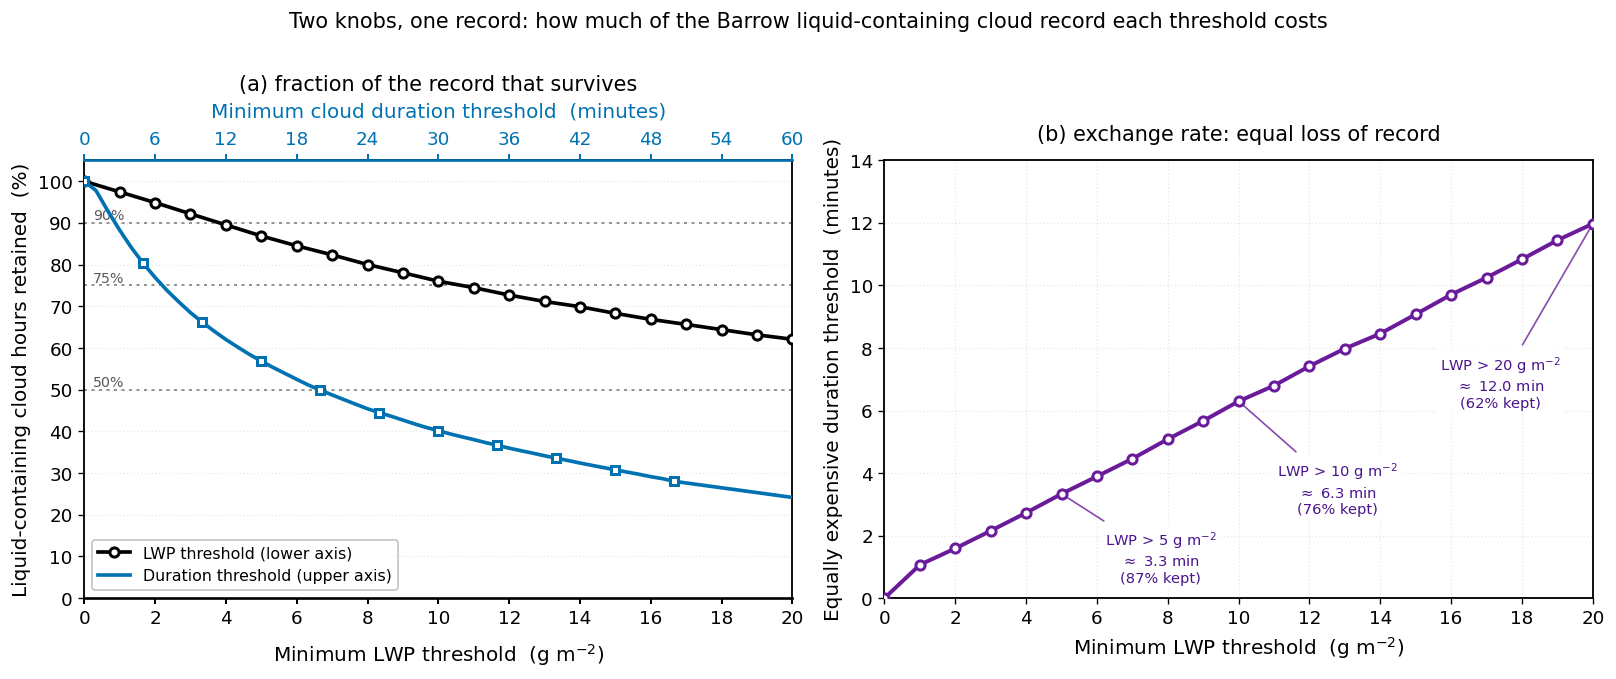

In [8]:
lwp_frac = lwp_total_h / lwp_total_h[0]
dur_frac = duration_total_h / duration_total_h[0]

# For each LWP threshold, invert the (monotone decreasing) duration curve.
equiv_duration_min = np.interp(
    lwp_frac[::-1], dur_frac[::-1], duration_threshold_min[::-1]
)[::-1]

fig, (axa, axb) = plt.subplots(1, 2, figsize=(13.6, 5.6))

# --- (a) retained fraction --------------------------------------------------
ax_dur2 = axa.twiny()
axa.plot(lwp_threshold_gm2, 100 * lwp_frac, "o-", color=C_LWP, lw=2.2, ms=5.5,
         mfc="white", mew=1.8, zorder=4, label="LWP threshold (lower axis)")
m = duration_threshold_min <= DUR_AXIS_MAX_MIN
ax_dur2.plot(duration_threshold_min[m], 100 * dur_frac[m], "-", color=C_DUR, lw=2.2,
             zorder=4, label="Duration threshold (upper axis)")
ax_dur2.plot(duration_threshold_min[m][::5], 100 * dur_frac[m][::5], "s", color=C_DUR,
             ms=5.0, mfc="white", mew=1.8, zorder=5)

axa.set_xlim(0, 20)
axa.xaxis.set_major_locator(MultipleLocator(2))
axa.set_xlabel(r"Minimum LWP threshold  (g m$^{-2}$)", color=C_LWP, labelpad=8)
axa.tick_params(axis="x", colors=C_LWP, width=1.2)
axa.spines["bottom"].set_color(C_LWP)
axa.spines["bottom"].set_linewidth(1.6)

ax_dur2.set_xlim(0, DUR_AXIS_MAX_MIN)
ax_dur2.xaxis.set_major_locator(MultipleLocator(6))
ax_dur2.set_xlabel("Minimum cloud duration threshold  (minutes)", color=C_DUR, labelpad=8)
ax_dur2.tick_params(axis="x", colors=C_DUR, width=1.2)
ax_dur2.spines["top"].set_color(C_DUR)
ax_dur2.spines["top"].set_linewidth(1.6)
for s in ("bottom", "left", "right"):
    ax_dur2.spines[s].set_visible(False)

axa.set_ylabel("Liquid-containing cloud hours retained  (%)")
axa.set_ylim(0, 105)
axa.yaxis.set_major_locator(MultipleLocator(10))
axa.grid(axis="y", alpha=0.28, ls=":")
axa.set_axisbelow(True)
for lvl in (90, 75, 50):
    axa.axhline(lvl, color="0.45", lw=0.9, ls=(0, (2, 3)), zorder=1)
    axa.annotate(f"{lvl}%", xy=(0.012, lvl), xycoords=("axes fraction", "data"),
                 va="bottom", ha="left", fontsize=8.5, color="0.35")

h = axa.get_legend_handles_labels()[0] + ax_dur2.get_legend_handles_labels()[0]
l = axa.get_legend_handles_labels()[1] + ax_dur2.get_legend_handles_labels()[1]
axa.legend(h, l, loc="lower left", fontsize=9.5)
axa.set_title("(a) fraction of the record that survives", pad=42)

# --- (b) exchange rate ------------------------------------------------------
axb.plot(lwp_threshold_gm2, equiv_duration_min, "o-", color="#6A1B9A", lw=2.4,
         ms=5.5, mfc="white", mew=1.8, zorder=4)
axb.set_xlabel(r"Minimum LWP threshold  (g m$^{-2}$)")
axb.set_ylabel("Equally expensive duration threshold  (minutes)")
axb.set_xlim(0, 20)
axb.set_ylim(0, 14)
axb.xaxis.set_major_locator(MultipleLocator(2))
axb.yaxis.set_major_locator(MultipleLocator(2))
axb.grid(alpha=0.28, ls=":")
axb.set_axisbelow(True)
axb.set_title("(b) exchange rate: equal loss of record", pad=12)

for x, tx, ty in ((5, 7.8, 1.3), (10, 12.8, 3.5), (20, 17.4, 6.9)):
    y = float(np.interp(x, lwp_threshold_gm2, equiv_duration_min))
    pct = 100 * float(np.interp(x, lwp_threshold_gm2, lwp_frac))
    axb.annotate(f"LWP > {x} g m$^{{-2}}$\n$\\approx$ {y:.1f} min\n({pct:.0f}% kept)",
                 xy=(x, y), xytext=(tx, ty), fontsize=8.8, ha="center", va="center",
                 color="#4A148C",
                 bbox=dict(boxstyle="round,pad=0.28", fc="white", ec="none", alpha=0.9),
                 arrowprops=dict(arrowstyle="-", color="#6A1B9A", lw=1.0, alpha=0.8))

fig.suptitle("Two knobs, one record: how much of the Barrow liquid-containing cloud "
             "record each threshold costs", y=1.005, fontsize=12.5)
fig.tight_layout()
fig.savefig(FIG_DIR / "barrow_liquid_hours_threshold_retention_and_exchange.png")
plt.show()

## 7. What the curves say

Read off panel (a):

| threshold | hours kept | % kept |
|---|---|---|
| none | 1451 | 100 |
| LWP > 5 g m$^{-2}$ | 1260 | 86.9 |
| LWP > 10 g m$^{-2}$ | 1103 | 76.0 |
| LWP > 20 g m$^{-2}$ | 901 | 62.1 |
| duration $\ge$ 5 min | 1215 | 80.3 |
| duration $\ge$ 10 min | 1001 | 66.2 |
| duration $\ge$ 20 min | 755 | 49.9 |

The duration threshold is by far the more expensive knob. Ten minutes of
required persistence costs 34% of the record; the entire 20 g m$^{-2}$ LWP
sweep, which is as far as Genie's figure goes, costs 38%. Panel (b) puts the
exchange rate at a nearly constant **0.6 min per g m$^{-2}$** across the whole
sweep (equivalently, 1 minute of required persistence costs about as much as
1.6 g m$^{-2}$ of LWP) -- so the full 20 g m$^{-2}$ LWP cut buys the same loss
as a 12-minute persistence requirement, and nothing milder.

The reason is in the cloud-length distribution reproduced in panel (c) of
section 3: it is steeply peaked at 1-3 min and has a long thin tail. Short
episodes are individually negligible but there are enough of them that they
carry a third of the total hours. The LWP curve, by contrast, is close to
linear over 0-20 g m$^{-2}$, losing about 27 h/season per g m$^{-2}$ -- there
is no pile-up of hours at low LWP the way there is at short duration.

By category, the two knobs do not fall on the same one, and `liq_mixed`
survives both best (74.5% retained at LWP > 20 g m$^{-2}$, 55.3% at 20 min,
against 45-50% and 27-48% for the other two). That is close to a definition:
an episode is classified `liq_mixed` only if it contains both a liquid-only
and a mixed-phase period, which forces it to be long, and long episodes carry
more liquid. The interesting split is between the other two categories. The
LWP knob bites hardest on `liq_only` (45.0% retained at 20 g m$^{-2}$, against
49.8% for `mixed_only`); the duration knob bites hardest on `mixed_only` by a
wide margin (27.3% retained at 20 min, against 47.9% for `liq_only`).
Purely mixed-phase episodes at Barrow are the short-lived ones.

In [9]:
# Per-category susceptibility, for the record.
print("fraction of each category retained\n")
print(f"{'threshold':<26s}" + "".join(f"{lab:>17s}" for lab in CAT_LABELS))
for x in (5, 10, 20):
    vals = "".join(f"{100 * lwp_hours[c][x] / lwp_hours[c][0]:16.1f}%" for c in CATS)
    print(f"{'LWP > ' + str(x) + ' g m-2':<26s}" + vals)
for t in (5, 10, 20):
    i = int(np.where(duration_threshold_min == t)[0][0])
    vals = "".join(f"{100 * duration_hours[c][i] / duration_hours[c][0]:16.1f}%" for c in CATS)
    print(f"{'duration >= ' + str(t) + ' min':<26s}" + vals)

fraction of each category retained

threshold                       liquid only   liquid + mixed       mixed only
LWP > 5 g m-2                         80.5%            92.3%            78.5%
LWP > 10 g m-2                        64.7%            85.2%            63.1%
LWP > 20 g m-2                        45.0%            74.5%            49.8%
duration >= 5 min                     79.2%            83.9%            64.9%
duration >= 10 min                    64.6%            71.0%            45.5%
duration >= 20 min                    47.9%            55.3%            27.3%
